In [1]:
#! pip install torchsummary
#! pip install pytorch-ignite

In [2]:
# Installa PyTorch con supporto MPS
#! pip install torch torchvision torchaudio

NN Pytorch

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.nn.init import xavier_normal_
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import MeanSquaredError, MeanAbsoluteError, Metric

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import Accuracy, Loss
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [6]:
print(f"MPS disponibile: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

MPS disponibile: True
MPS built: True


In [7]:
x_train = (pd.read_csv('data/regression/X_train_rating_no_out_regression.csv')).drop('Unnamed: 0', axis =1)
y_train = pd.read_csv('data/regression/y_train_rating_no_out_regression.csv')

x_test = (pd.read_csv('data/regression/X_test_rating_regression.csv')).drop('Unnamed: 0', axis =1)
y_test = pd.read_csv('data/regression/y_test_rating_regression.csv')

In [8]:
y_train = y_train['averageRating']
y_test = y_test['averageRating']

In [9]:
# log transformation delle seguenti colonne: runtimeminutes, numvotes, totalcredits, userrewtotal, totalmedia
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [10]:
scaler = StandardScaler()
num_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
        'companiesNumber', 'externalLinks', 'writerCredits',
        'directorsCredits', 'quotesTotal', 'totalMedia', 'totalNominations']

scaler.fit(x_train[num_cols])

StandardScaler()

In [11]:
x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [12]:
folds = KFold(n_splits=5, shuffle = True, random_state= 42)

## Costruzione rete

In [13]:
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

## Setting della rete

In [14]:
x_train_tensor = torch.tensor(x_train_split.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [15]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [17]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [18]:
class NNRegressor(nn.Module):

    def __init__(self, input_dim, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size):
        super(NNRegressor, self).__init__()

        self.input_layer = nn.Linear(input_dim, hidden_size1)
        self.dropout1 = nn.Dropout(0.2)  # Salva come attributo
        self.hidden_layer1 = nn.Linear(hidden_size1, hidden_size2)
        self.dropout2 = nn.Dropout(0.2)
        self.hidden_layer2 = nn.Linear(hidden_size2, hidden_size3)
        self.dropout3 = nn.Dropout(0.2)
        self.hidden_layer3 = nn.Linear(hidden_size3, hidden_size4)
        self.dropout4 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(hidden_size4, output_size)
        self.relu = nn.ReLU()

        self.relu = nn.ReLU()
    # Applicazione delle funzioni di attivazione per ogni strato
    def forward(self, x):
        x = self.relu(self.input_layer(x))
        x = self.relu(self.hidden_layer1(x))
        x = self.relu(self.hidden_layer2(x))
        x = self.relu(self.hidden_layer3(x))
        x = self.output_layer(x)

        return x.squeeze()


In [19]:
input_size = x_train.shape[1] # ci devono essere tanti neuroni quante istanze da considerare
hidden_size1 = 256
hidden_size2 = 128
hidden_size3 = 64
hidden_size4 = 64
output_size = 1 # settato ad 1 perché l'output della regressione deve essere un singolo valore

In [20]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [21]:
model = NNRegressor(input_size, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr= 0.001, weight_decay=1e-4)
criterion = nn.MSELoss()

In [22]:
class R2Score(Metric):
    def __init__(self, output_transform=lambda x: x, device=device):
        super(R2Score, self).__init__(output_transform=output_transform, device=device)

    def reset(self):
        self.sum_squared_residuals = 0.0
        self.sum_squared_totals = 0.0
        self._y_true = []
        self._y_pred = []

    def update(self, output):
        y_pred, y_true = output
        y_pred = y_pred.detach()
        y_true = y_true.detach()

        self._y_pred.append(y_pred)
        self._y_true.append(y_true)

    def compute(self):
        y_pred = torch.cat(self._y_pred)
        y_true = torch.cat(self._y_true)
        y_mean = torch.mean(y_true)

        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - y_mean) ** 2)

        r2 = 1 - ss_res / ss_tot
        return r2.item()

In [23]:
trainer = create_supervised_trainer(model, optimizer, criterion, device)

In [24]:
val_metrics = {"mean_squared_error": MeanSquaredError(device=device), "mean_absolute_error": MeanAbsoluteError(device=device), 'r2': R2Score(device=device)}

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

training_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2' :[] }
validation_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2': []}

In [25]:
log_interval = 100

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.2f}")

# after a training epoch, computes training and validation metrics (train_eval on train_loader and val_eval on val_loader)
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    training_history['mean_squared_error'].append(metrics['mean_squared_error'])
    training_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    training_history['r2'].append(metrics['r2'])
    print(f"Training Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    validation_history['mean_squared_error'].append(metrics['mean_squared_error'])
    validation_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    validation_history['r2'].append(metrics['r2'])
    print(f"Validation Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

In [26]:
def score_function(engine):
    y_pred, y_true = engine.state.output
    return r2_score(y_true.cpu().numpy(), y_pred.cpu().numpy())

In [27]:
handler = EarlyStopping(patience = 20, score_function=score_function, trainer = trainer)

checkpoint = ModelCheckpoint(dirname='models',
    filename_prefix='best_NOREG',
    n_saved=1,
    create_dir=True,
    global_step_transform=global_step_from_engine(trainer))

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {'model': model})

In [28]:
trainer.state.max_epochs = None
trainer.state.epoch = 0
trainer.run(train_loader, max_epochs=100)

Epoch[1], Iter[100] Loss: 19.24
Epoch[1], Iter[200] Loss: 1.99
Epoch[1], Iter[300] Loss: 1.84
Epoch[1], Iter[400] Loss: 0.95
Epoch[1], Iter[500] Loss: 1.41
Epoch[1], Iter[600] Loss: 1.08
Epoch[1], Iter[700] Loss: 1.77
Epoch[1], Iter[800] Loss: 2.79
Epoch[1], Iter[900] Loss: 1.18
Epoch[1], Iter[1000] Loss: 2.03
Epoch[1], Iter[1100] Loss: 2.83
Epoch[1], Iter[1200] Loss: 1.43
Epoch[1], Iter[1300] Loss: 0.54
Epoch[1], Iter[1400] Loss: 1.68
Epoch[1], Iter[1500] Loss: 1.65
Epoch[1], Iter[1600] Loss: 1.25
Epoch[1], Iter[1700] Loss: 0.99
Epoch[1], Iter[1800] Loss: 1.67
Epoch[1], Iter[1900] Loss: 1.41
Epoch[1], Iter[2000] Loss: 0.81
Epoch[1], Iter[2100] Loss: 1.03
Epoch[1], Iter[2200] Loss: 1.14
Training Results - Epoch[1] MeanSquaredError: 1.42 MeanAbsoluteError: 0.89 R2: 0.21
Validation Results - Epoch[1] MeanSquaredError: 1.40 MeanAbsoluteError: 0.88 R2: 0.21
Epoch[2], Iter[2300] Loss: 1.79
Epoch[2], Iter[2400] Loss: 1.37
Epoch[2], Iter[2500] Loss: 1.98
Epoch[2], Iter[2600] Loss: 1.83
Epoch[

2025-08-24 18:11:16,596 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch[21] MeanSquaredError: 1.19 MeanAbsoluteError: 0.80 R2: 0.33


State:
	iteration: 46725
	epoch: 21
	epoch_length: 2225
	max_epochs: 100
	output: 0.3535478413105011
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

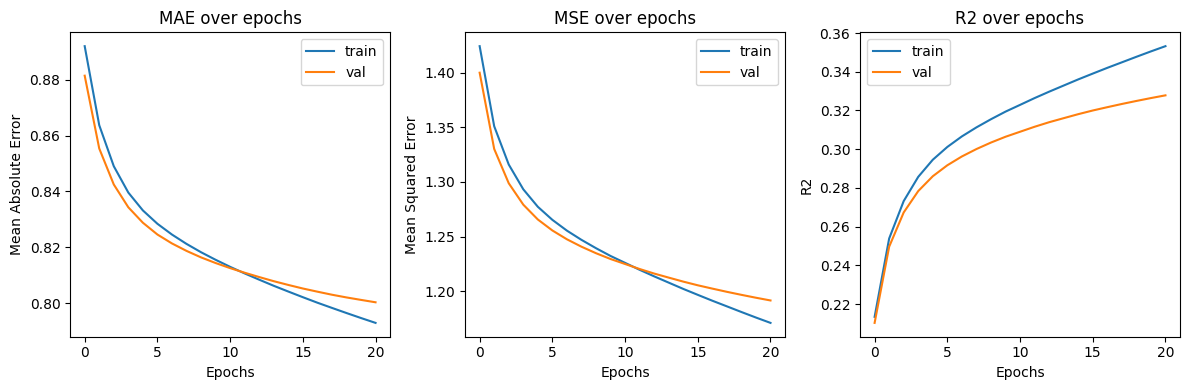

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# Plot MAE
axes[0].plot(training_history['mean_absolute_error'], label='train')
axes[0].plot(validation_history['mean_absolute_error'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE over epochs')
axes[0].legend()

# Plot MSE
axes[1].plot(training_history['mean_squared_error'], label='train')
axes[1].plot(validation_history['mean_squared_error'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('MSE over epochs')
axes[1].legend()

# Plot R2
axes[2].plot(training_history['r2'], label='train')
axes[2].plot(validation_history['r2'], label='val')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('R2')
axes[2].set_title('R2 over epochs')
axes[2].legend()

fig.tight_layout()
plt.show()

In [31]:
best_model = NNRegressor(input_size, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size)
best_model.load_state_dict(torch.load('models/best_NOREG_model_21.pt'))
best_model.to(device)

NNRegressor(
  (input_layer): Linear(in_features=58, out_features=256, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (hidden_layer1): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (hidden_layer2): Linear(in_features=128, out_features=64, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (hidden_layer3): Linear(in_features=64, out_features=64, bias=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

In [32]:
criterion = nn.CrossEntropyLoss().to(device)  # same criterion used while training
metrics = {"mean_squared_error": MeanSquaredError(device=device), "mean_absolute_error": MeanAbsoluteError(device=device), 'r2': R2Score(device=device)} # same metrics used while training

In [33]:
def evaluate_model(evaluator, test_loader):
    state = evaluator.run(test_loader)
    metrics = evaluator.state.metrics
    test_MSE = metrics['mean_squared_error']
    test_MAE = metrics['mean_absolute_error']
    test_R2 = metrics['r2']

    return test_MSE, test_MAE, test_R2

In [34]:
NOREG_evaluator = create_supervised_evaluator(best_model, metrics=metrics, device=device) 
loss_ES, acc_ES, test_R2 = evaluate_model(NOREG_evaluator, test_loader)
print("Model with regularization - MSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}".format(loss_ES, acc_ES, test_R2))

Model with regularization - MSE: 1.2320, MAE: 0.8063, R2: 0.3142
